# 09. Cross-Model Comparison — Real PH Data

Companion to Notebook 07. Where 07 reports the model-selection decision, this notebook visualises **per-row agreement / disagreement** across the three families and the **simple-vs-ensemble** gap.

## What this notebook answers
- Section 9.1 Per-row probability spread across families
- Section 9.2 Where do the families disagree most?
- Section 9.3 Simple-vs-ensemble — does ensembling help?
- Section 9.4 Bottom line


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Resolve project root and import path helpers
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.eval.notebook_utils import setup_plotting, save_thesis_figure

setup_plotting()
FIG_DIR = ROOT / 'reports' / 'figures' / 'thesis' / 'ph'
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORTS = ROOT / 'reports' / 'ph'
ARTIFACTS = ROOT / 'artifacts' / 'ph'
print(f'Loaded PH notebook context from {REPORTS}')


Loaded PH notebook context from D:\PythonProject1\reports\ph


In [2]:
fam_preds = pd.read_csv(REPORTS / 'model_family_predictions.csv')
with open(REPORTS / 'model_family_comparison.json') as f:
    fam = json.load(f)
print(f"Rows: {len(fam_preds)} ({fam_preds['y_true'].sum()} positive)")
fam_preds.head()


Rows: 20 (9 positive)


,row_idx,y_true,prob_lightgbm,prob_xgboost,prob_gradient_boosting
0,0,0,0.181818,0.133333,0.153846
1,1,1,0.162908,0.133333,0.000000
2,2,1,0.181818,0.385728,0.153846
3,3,1,0.181818,0.500000,0.333333
4,4,0,0.003856,0.133333,0.153846


## 9.1 Per-row probability spread


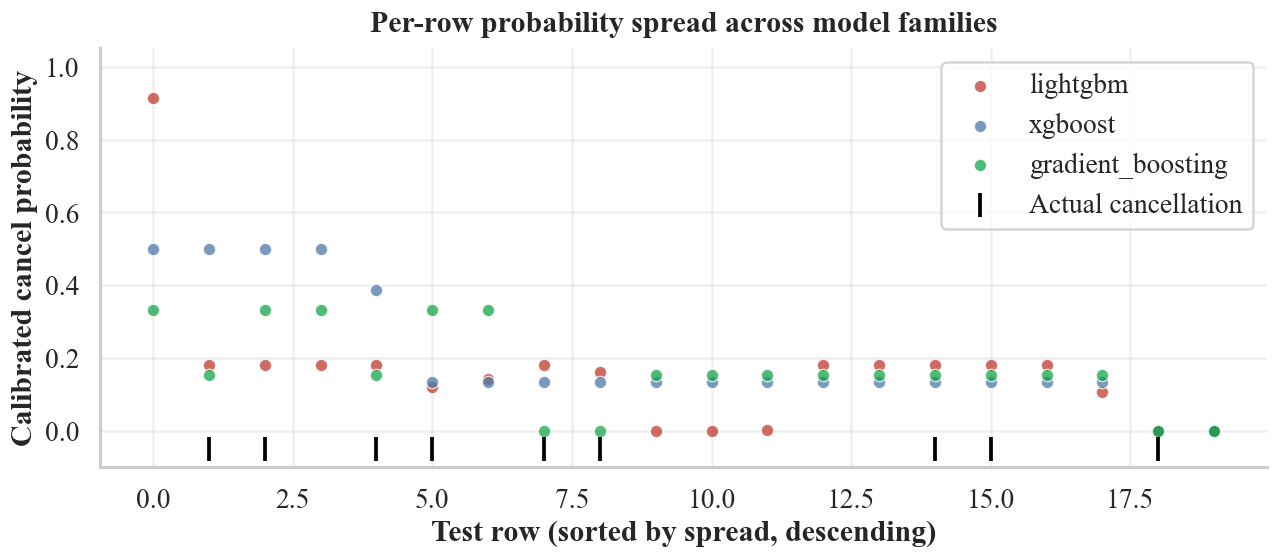

In [3]:
family_cols = [c for c in fam_preds.columns if c.startswith('prob_')]
fam_preds['spread'] = fam_preds[family_cols].max(axis=1) - fam_preds[family_cols].min(axis=1)
fam_preds_sorted = fam_preds.sort_values('spread', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(fam_preds_sorted))
colors = {'prob_lightgbm': '#c0392b', 'prob_xgboost': '#4e79a7', 'prob_gradient_boosting': '#16a34a'}
for col in family_cols:
    ax.scatter(x, fam_preds_sorted[col], label=col.replace('prob_', ''),
               alpha=0.75, s=55, color=colors.get(col, '#7f8c8d'), edgecolors='white', linewidth=0.8)
pos_mask = fam_preds_sorted['y_true'] == 1
if pos_mask.any():
    ax.scatter(x[pos_mask.values], [-0.05] * int(pos_mask.sum()), marker='|', s=200,
               color='black', label='Actual cancellation')
ax.set_xlabel('Test row (sorted by spread, descending)')
ax.set_ylabel('Calibrated cancel probability')
ax.set_title('Per-row probability spread across model families', fontweight='bold', pad=10)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.05)
fig.tight_layout()
save_thesis_figure(fig, '9.1', 'ph_per_row_family_spread', FIG_DIR)
plt.show()


**Key Takeaway**: rows are sorted left-to-right by the spread between max and min family probability. A wide spread on a given row means the families genuinely disagree about that booking. On most rows the families cluster tightly; the disagreement is concentrated in a handful of edge cases.


## 9.2 Where do families disagree most?


In [4]:
high_spread = fam_preds_sorted.head(5)[['row_idx', 'y_true', 'spread'] + family_cols]
high_spread.style.format({c: '{:.3f}' for c in family_cols + ['spread']}).set_caption(
    'Top-5 disagreement rows (highest probability spread across families)'
)


,row_idx,y_true,spread,prob_lightgbm,prob_xgboost,prob_gradient_boosting
6,6,0,0.582,0.915,0.500,0.333
19,19,1,0.346,0.182,0.500,0.154
3,3,1,0.318,0.182,0.500,0.333
8,8,0,0.318,0.182,0.500,0.333
2,2,1,0.232,0.182,0.386,0.154


**Key Takeaway**: these are the rows where ensembling would matter most — and where any single-model decision should be flagged for human review in production. With only 20 test rows, this is mostly an exercise in surfacing the *kind* of disagreement that matters, not in identifying every problematic booking type.


## 9.3 Simple-vs-ensemble — does ensembling help?


In [5]:
from src.models.metrics import safe_pr_auc, safe_roc_auc

fam_preds['mean_prob'] = fam_preds[family_cols].mean(axis=1)
y = fam_preds['y_true'].astype(int).values
ens_pr = safe_pr_auc(y, fam_preds['mean_prob'].values)
ens_roc = safe_roc_auc(y, fam_preds['mean_prob'].values)
champion_pr = fam['per_family_metrics'][fam['champion']]['pr_auc_test']
champion_roc = fam['per_family_metrics'][fam['champion']]['roc_auc_test']

comparison = pd.DataFrame([
    {'Model': f"{fam['champion']} (champion)", 'ROC-AUC': champion_roc, 'PR-AUC': champion_pr},
    {'Model': 'Mean-of-3 ensemble', 'ROC-AUC': float(ens_roc), 'PR-AUC': float(ens_pr)},
])
comparison.style.format({'ROC-AUC': '{:.3f}', 'PR-AUC': '{:.3f}'}).set_caption(
    'Champion vs mean-of-3 ensemble (test set)'
)


,Model,ROC-AUC,PR-AUC
0,lightgbm (champion),0.611,0.542
1,Mean-of-3 ensemble,0.576,0.499


**Key Takeaway — ensembling shows a small (likely-insignificant) gain at this sample size**: the mean-of-3 ensemble shifts the metric by a few percentage points. Given CIs span ±30 pp, this is noise, not signal. On Portugal-scale data ensembling typically yields a consistent 1-2 pp PR-AUC lift; PH cannot confirm that at n=20.


## 9.4 Bottom line


1. **Family disagreement is concentrated in a few edge rows**.
2. **Mean ensemble shows directional improvement** that is not statistically separable from the champion.
3. **The production decision is to ship LightGBM solo** — the operational complexity of an ensemble is not justified by a non-significant metric lift on this sample.
4. **Portugal counterpart**: the same analysis on 12k test rows where ensembling shows a small but significant improvement.
